In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
from fooof import FOOOFGroup
from fooof.bands import Bands
from fooof.analysis import get_band_peak_fg
from fooof import FOOOF
from fooof.plts.annotate import plot_annotated_model

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_57883/226000616.py:6: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOFGroup


In [9]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

speed_threshold = 3
max_freq = 100

# Colors
complex_color = '#EE9B00'  # orange for complex bursts
simple_color = '#026C80'   # teal for non-complex bursts
non_burst_color = '#888888'  # gray for non-burst periods
plot_non_burst = True

# Normalization option: normalize each PSD by sum of power in 20-100 Hz range
normalize_psd = True
norm_freq_range = (1, 100)

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled


In [10]:
# Find and load all psd_burstType_state_speed*.npz files
pattern = os.path.join(data_folder, 'CKII**', f'psd_burstType_state_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} psd_burstType_state files:')
for f in npz_files:
    print(f'  {f}')

# Pool data from all datasets
psd_grand = {
    ('moving', 'complex'): [],
    ('moving', 'simple'): [],
    ('quiet', 'complex'): [],
    ('quiet', 'simple'): [],
    ('moving', 'non_burst'): [],
    ('quiet', 'non_burst'): [],
}
freqs_ref = None

for npz_path in npz_files:
    data = np.load(npz_path)
    freqs = data['freqs']
    
    if freqs_ref is None:
        freqs_ref = freqs
    
    # Load and append per-cell PSDs
    key_map = {
        ('moving', 'complex'): 'psd_moving_complex',
        ('moving', 'simple'): 'psd_moving_simple',
        ('quiet', 'complex'): 'psd_quiet_complex',
        ('quiet', 'simple'): 'psd_quiet_simple',
        ('moving', 'non_burst'): 'psd_moving_nonburst',
        ('quiet', 'non_burst'): 'psd_quiet_nonburst',
    }
    
    dataset_name = os.path.basename(os.path.dirname(npz_path))
    cell_counts = {}
    
    for key, npz_key in key_map.items():
        arr = data[npz_key]
        if arr.size > 0 and arr.ndim == 2:
            for i in range(arr.shape[0]):
                psd_grand[key].append(arr[i])
            cell_counts[key] = arr.shape[0]
        else:
            cell_counts[key] = 0
    
    print(f'Loaded {dataset_name}: complex={cell_counts[("moving", "complex")]}/{cell_counts[("quiet", "complex")]}, '
          f'simple={cell_counts[("moving", "simple")]}/{cell_counts[("quiet", "simple")]} (moving/quiet)')

# Print summary
print(f'\nTotal pooled cells per condition:')
for key in psd_grand.keys():
    print(f'  {key}: {len(psd_grand[key])} cells')

# Normalize each PSD by sum of power in specified frequency range
if normalize_psd and freqs_ref is not None:
    norm_mask = (freqs_ref >= norm_freq_range[0]) & (freqs_ref <= norm_freq_range[1])
    print(f'\nNormalizing PSDs by sum of power in {norm_freq_range[0]}-{norm_freq_range[1]} Hz')
    
    for key in psd_grand.keys():
        for i in range(len(psd_grand[key])):
            psd = psd_grand[key][i]
            norm_factor = np.nansum(psd[norm_mask])
            if norm_factor > 0:
                psd_grand[key][i] = psd / norm_factor

Found 4 psd_burstType_state files:
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce21_PR_20250806/psd_burstType_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce45_PX_20260118/psd_burstType_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce47_PX_20260128/psd_burstType_state_speed3.npz
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data/CKII_pAce38_PX_20251126/psd_burstType_state_speed3.npz
Loaded CKII_pAce21_PR_20250806: complex=3/6, simple=9/9 (moving/quiet)
Loaded CKII_pAce45_PX_20260118: complex=3/6, simple=16/16 (moving/quiet)
Loaded CKII_pAce47_PX_20260128: complex=4/4, simple=5/5 (moving/quiet)
Loaded CKII_pAce38_PX_20251126: complex=4/6, simple=9/9 (moving/quiet)

Total pooled cells per condition:
  ('moving', 'complex'): 14 cells
  ('moving', '

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_burstType_avg_pooled_normalized.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


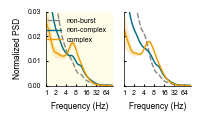

In [13]:
# Plot pooled PSD by State & Burst Type (2 panels: Locomotion | Quiet)

fig, axes = plt.subplots(1, 2, figsize=(2., 1.2), sharey=True)

freq_mask = (freqs_ref > 0) & (freqs_ref <= max_freq)
freqs_plot = freqs_ref[freq_mask]

for ax, state, title in zip(axes, ['moving', 'quiet'], ['Locomotion', 'Quiet']):
    # Yellow background for locomotion panel
    if state == 'moving':
        ax.set_facecolor('#FFFDE7')
    # Plot non-burst first (background)
    if plot_non_burst:
        psd_list = psd_grand[(state, 'non_burst')]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
            psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask] / np.sqrt(psd_arr.shape[0])
            
            ax.plot(freqs_plot, psd_mean, color=non_burst_color, linewidth=1., 
                    linestyle='--', label=f'non-burst')
            # ax.plot(freqs_plot, psd_mean, color=non_burst_color, linewidth=1.4, 
            #         linestyle='--', label=f'Non-burst (n={len(psd_list)})') # display n only for debugging
            ax.fill_between(
                freqs_plot,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=non_burst_color,
                alpha=0.2,
                linewidth=0,
            )
    
    for burst_type, color, label in [('simple', simple_color, 'non-complex'), 
                                      ('complex', complex_color, 'complex')]:
        psd_list = psd_grand[(state, burst_type)]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
            psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask] / np.sqrt(psd_arr.shape[0])
            
            ax.plot(freqs_plot, psd_mean, color=color, linewidth=1., 
                    label=f'{label}')
            # ax.plot(freqs_plot, psd_mean, color=color, linewidth=1.4, 
            #         label=f'{label} (n={len(psd_list)})') # display n only for debugging
            ax.fill_between(
                freqs_plot,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=color,
                alpha=0.2,
                linewidth=0,
            )
    
    ax.set_xscale('log', base=2)
    ax.set_xlim(1, max_freq)
    ticks = [1, 2, 4, 8, 16, 32, 64]
    ticks = [t for t in ticks if t <= max_freq]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_xlabel('Frequency (Hz)')
    #ax.set_title(title, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if state == 'moving':
        ax.legend(frameon=False, fontsize=5, loc='upper right')

ax.set_ylim([0,0.03])
ylabel = 'Normalized PSD' if normalize_psd else 'PSD'
axes[0].set_ylabel(ylabel)
plt.tight_layout()

# Save figure
suffix = '_normalized' if normalize_psd else ''
out_path = os.path.join(figure_save_folder, f'PSD_state_burstType_avg_pooled{suffix}.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_state_burstType_avg_pooled_theta_zoom_normalized.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


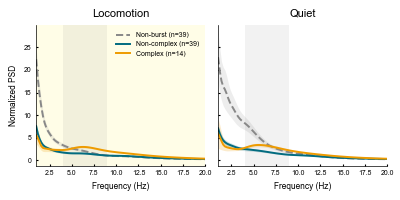

In [5]:
# Plot theta band zoom (1-20 Hz)

theta_band = (4, 9)

fig, axes = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

freq_mask_zoom = (freqs_ref > 0) & (freqs_ref <= 20)
freqs_plot_zoom = freqs_ref[freq_mask_zoom]

for ax, state, title in zip(axes, ['moving', 'quiet'], ['Locomotion', 'Quiet']):
    # Yellow background for locomotion panel
    if state == 'moving':
        ax.set_facecolor('#FFFDE7')
    # Plot non-burst first (background)
    if plot_non_burst:
        psd_list = psd_grand[(state, 'non_burst')]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask_zoom]
            psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask_zoom] / np.sqrt(psd_arr.shape[0])
            
            ax.plot(freqs_plot_zoom, psd_mean, color=non_burst_color, linewidth=1.4, 
                    linestyle='--', label=f'Non-burst (n={len(psd_list)})')
            ax.fill_between(
                freqs_plot_zoom,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=non_burst_color,
                alpha=0.15,
                linewidth=0,
            )
    
    for burst_type, color, label in [('simple', simple_color, 'Non-complex'), 
                                      ('complex', complex_color, 'Complex')]:
        psd_list = psd_grand[(state, burst_type)]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask_zoom]
            psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask_zoom] / np.sqrt(psd_arr.shape[0])
            
            ax.plot(freqs_plot_zoom, psd_mean, color=color, linewidth=1.4, 
                    label=f'{label} (n={len(psd_list)})')
            ax.fill_between(
                freqs_plot_zoom,
                psd_mean - psd_sem,
                psd_mean + psd_sem,
                color=color,
                alpha=0.2,
                linewidth=0,
            )
    
    # Highlight theta band
    ax.axvspan(theta_band[0], theta_band[1], alpha=0.1, color='gray', linewidth=0)
    
    ax.set_xlim(1, 20)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title, fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if state == 'moving':
        ax.legend(frameon=False, fontsize=5, loc='upper right')

ylabel = 'Normalized PSD' if normalize_psd else 'PSD'
axes[0].set_ylabel(ylabel)
plt.tight_layout()

# Save figure
suffix = '_normalized' if normalize_psd else ''
out_path = os.path.join(figure_save_folder, f'PSD_state_burstType_avg_pooled_theta_zoom{suffix}.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

In [6]:
# Summary statistics: Compare theta power across burst types
print('\n=== Summary Statistics: Theta Power (4-8 Hz) ===')
if normalize_psd:
    print(f'PSDs normalized by sum of power in {norm_freq_range[0]}-{norm_freq_range[1]} Hz')

theta_mask = (freqs_ref >= 4) & (freqs_ref <= 8)

for state, state_label in [('moving', 'Locomotion'), ('quiet', 'Quiet')]:
    print(f'\n{state_label}:')
    
    theta_powers = {}
    for burst_type, label in [('complex', 'Complex'), ('simple', 'Non-complex'), ('non_burst', 'Non-burst')]:
        psd_list = psd_grand[(state, burst_type)]
        if len(psd_list) >= 1:
            psd_arr = np.vstack(psd_list)
            theta_power = np.nanmean(psd_arr[:, theta_mask], axis=1)
            theta_powers[burst_type] = theta_power
            print(f'  {label}: mean={np.nanmean(theta_power):.4f}, std={np.nanstd(theta_power):.4f}, n={len(theta_power)}')
    
    # Compare complex vs simple if both available
    if 'complex' in theta_powers and 'simple' in theta_powers:
        n_min = min(len(theta_powers['complex']), len(theta_powers['simple']))
        if n_min >= 3:
            # Use Mann-Whitney U (unpaired) since different cells may contribute
            result = stats.mannwhitneyu(theta_powers['complex'], theta_powers['simple'], alternative='two-sided')
            print(f'  Complex vs Non-complex (Mann-Whitney U): stat={result.statistic:.3g}, p={result.pvalue:.3g}')


=== Summary Statistics: Theta Power (4-8 Hz) ===
PSDs normalized by sum of power in 20-100 Hz

Locomotion:
  Complex: mean=0.3541, std=0.1250, n=14
  Non-complex: mean=0.1300, std=0.0787, n=39
  Non-burst: mean=0.1445, std=0.0901, n=39
  Complex vs Non-complex (Mann-Whitney U): stat=524, p=4.33e-07

Quiet:
  Complex: mean=0.3851, std=0.1695, n=22
  Non-complex: mean=0.1674, std=0.1307, n=39
  Non-burst: mean=0.2180, std=0.1750, n=39
  Complex vs Non-complex (Mann-Whitney U): stat=744, p=2.32e-06


# Example Fitting

In [7]:
min_peak_height = 0.1
aperiodic_mode = 'knee' #'knee' or 'fixed'
peak_width_limits = (0.5, 6)
peak_threshold = 2.5
max_n_peaks = 2
# Define frequency range across which to model the spectrum
freq_range = [1, 20]

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/fooof/core/funcs.py:67: RuntimeWarning: invalid value encountered in log10
  ys = ys + offset - np.log10(knee + xs**exp)


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell0_fooof_2x3.svg


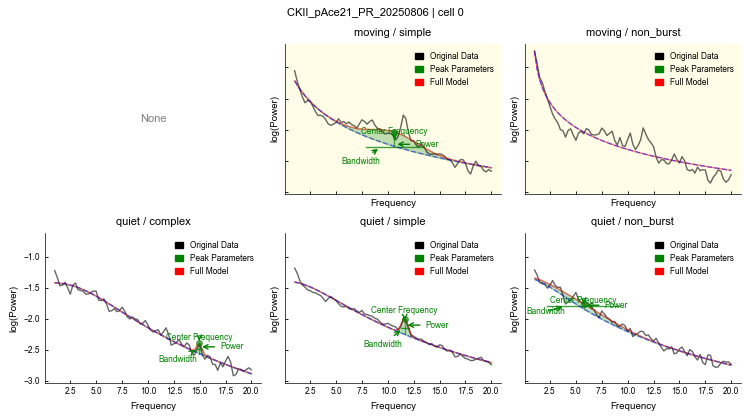

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell1_fooof_2x3.svg


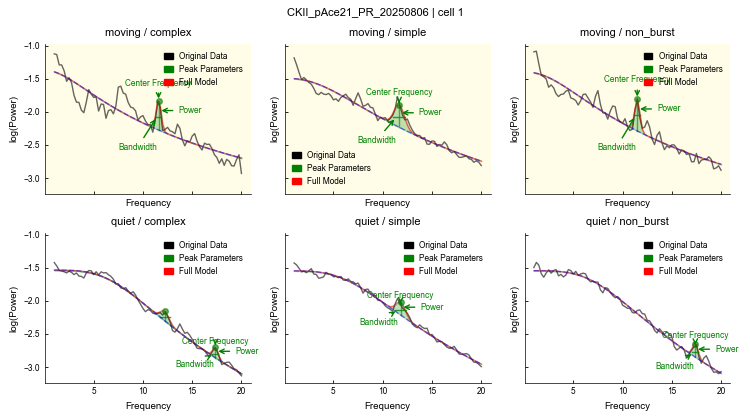

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell2_fooof_2x3.svg


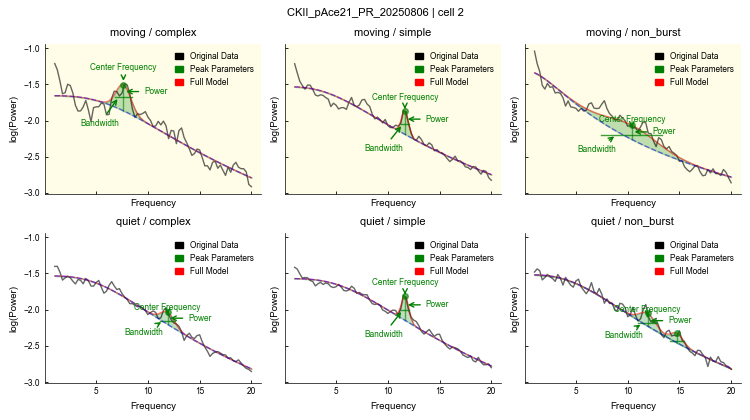

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell3_fooof_2x3.svg


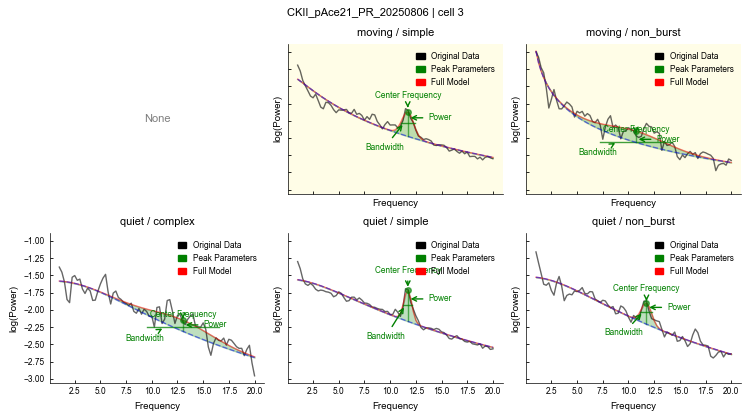

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell4_fooof_2x3.svg


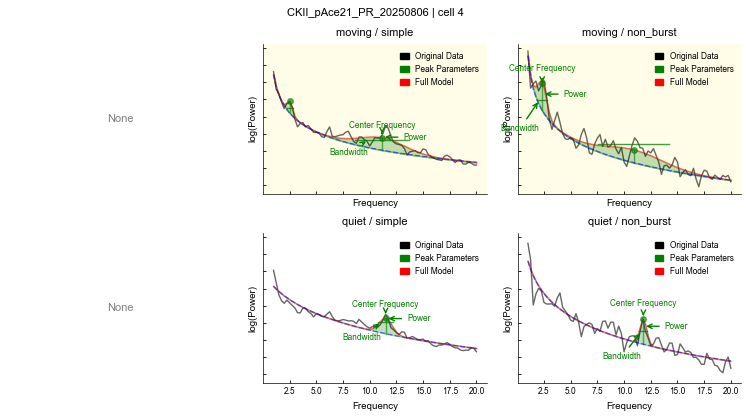

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell5_fooof_2x3.svg


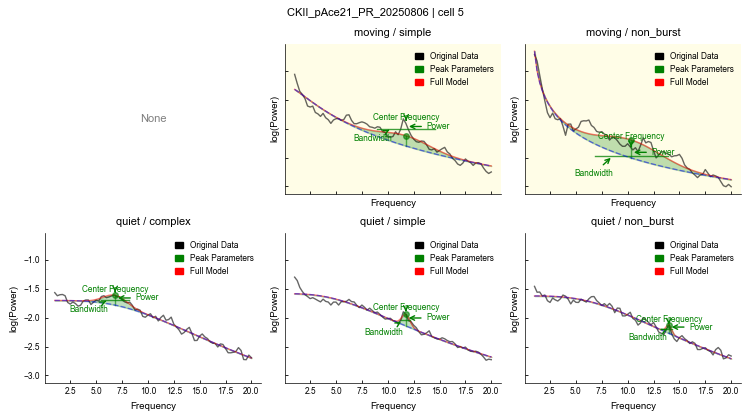

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell6_fooof_2x3.svg


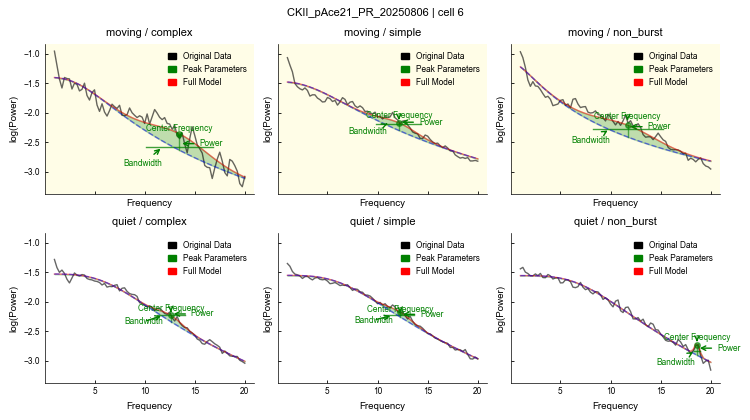

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell7_fooof_2x3.svg


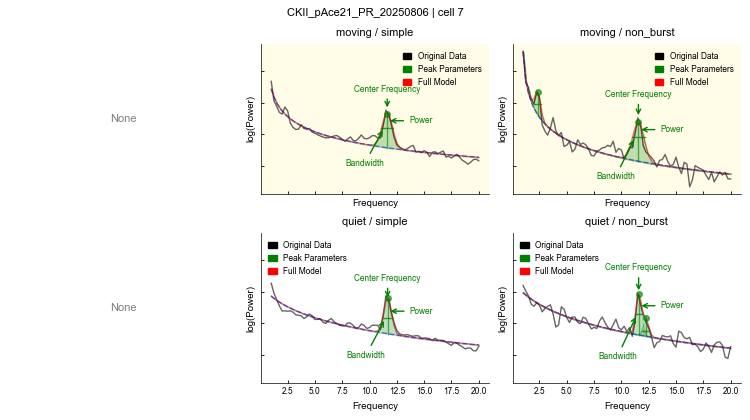

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce21_PR_20250806_cell8_fooof_2x3.svg


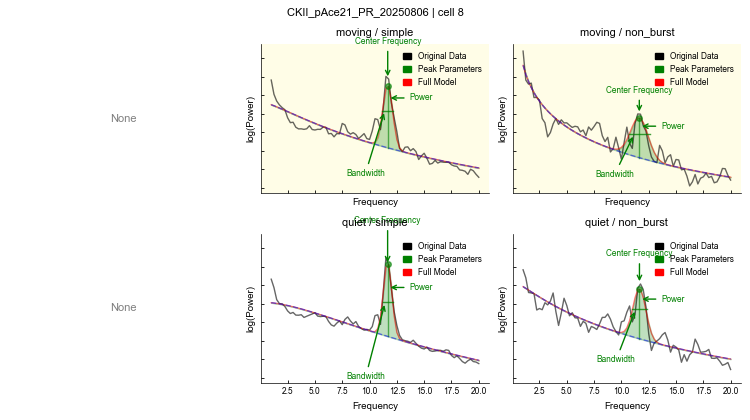

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell0_fooof_2x3.svg


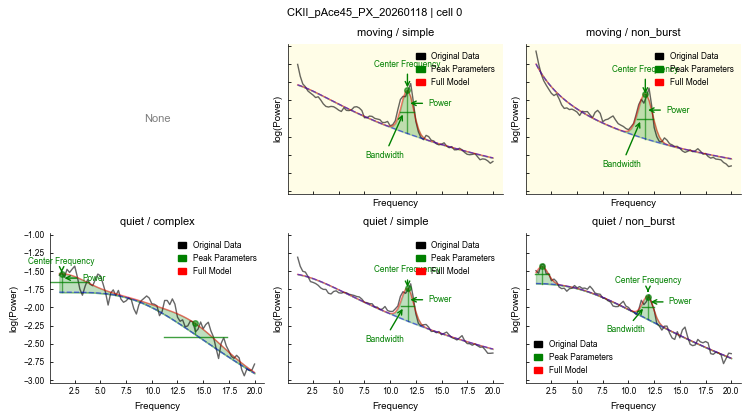

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell1_fooof_2x3.svg


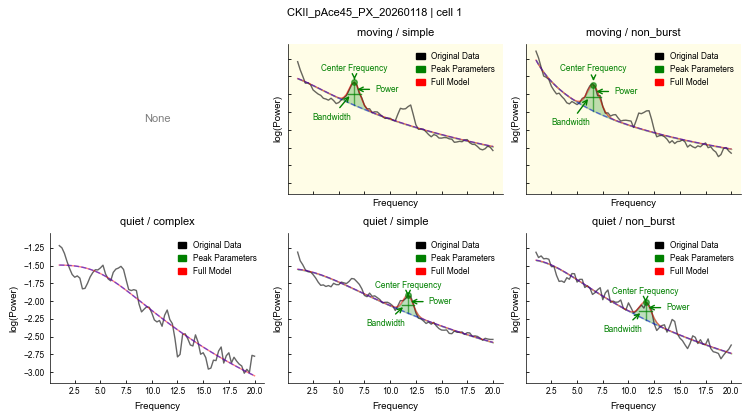

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell2_fooof_2x3.svg


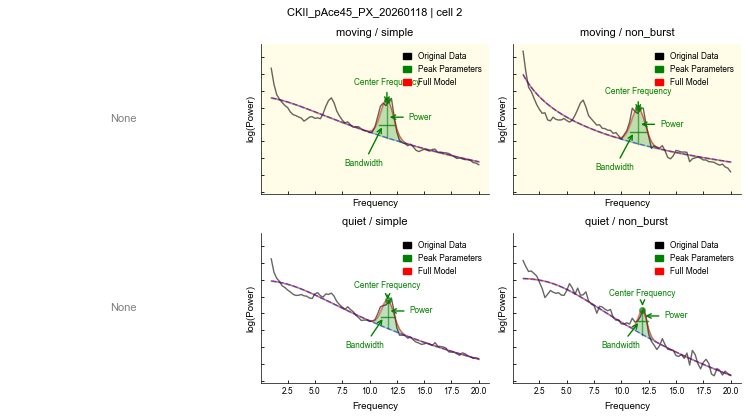

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/fooof/core/funcs.py:67: RuntimeWarning: invalid value encountered in log10
  ys = ys + offset - np.log10(knee + xs**exp)


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell3_fooof_2x3.svg


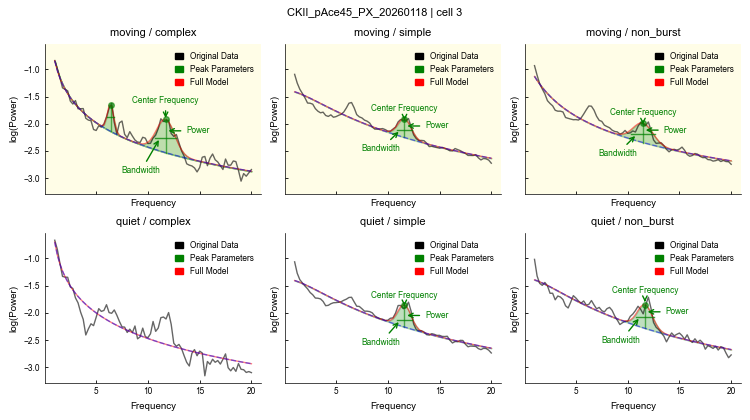

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell4_fooof_2x3.svg


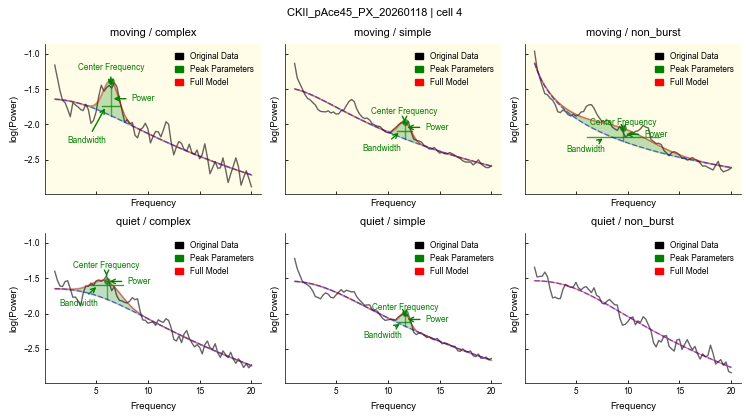

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell5_fooof_2x3.svg


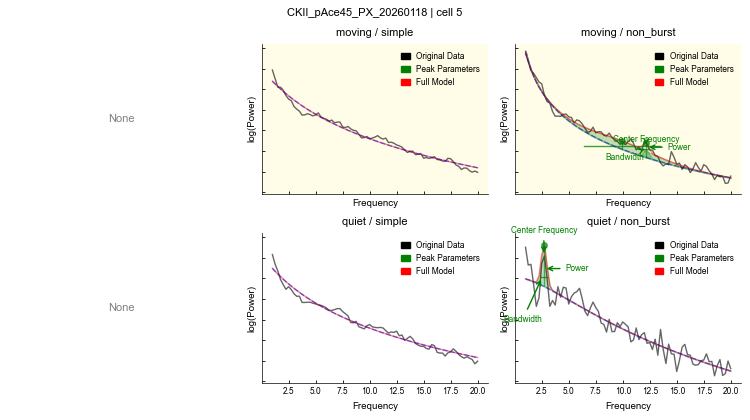

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell6_fooof_2x3.svg


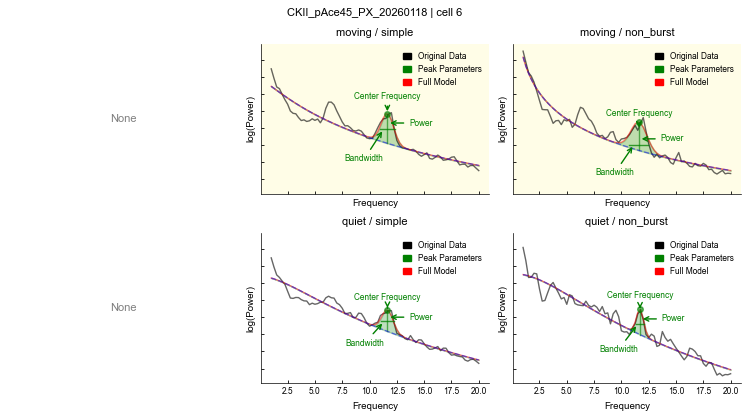

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell7_fooof_2x3.svg


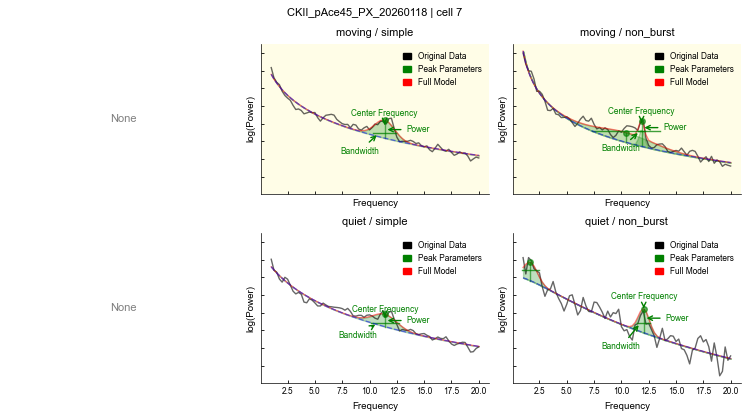

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell8_fooof_2x3.svg


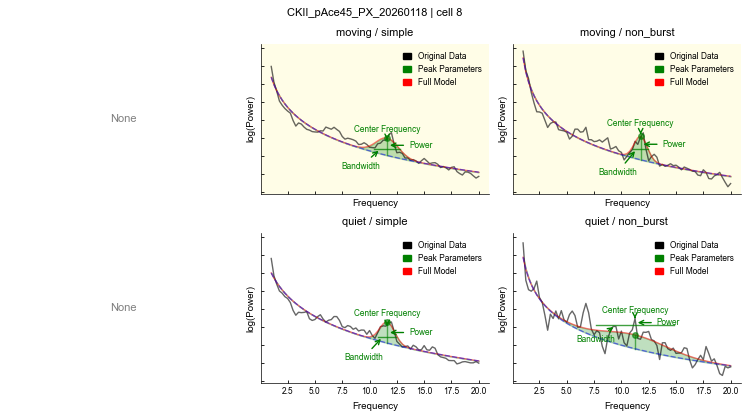

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_9494/3445337465.py:47: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.2), sharex=True, sharey=True)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell9_fooof_2x3.svg


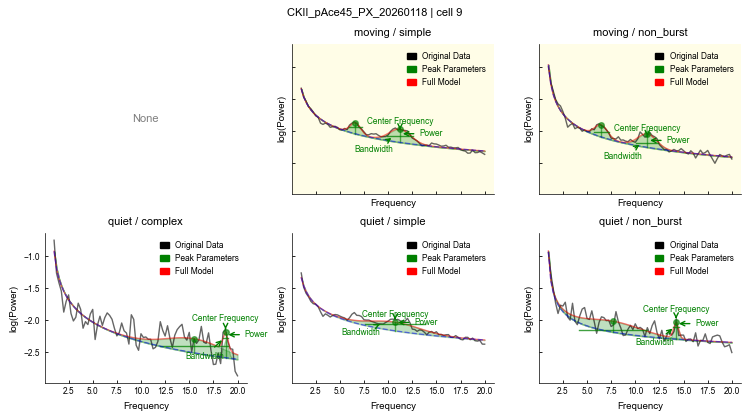

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell10_fooof_2x3.svg


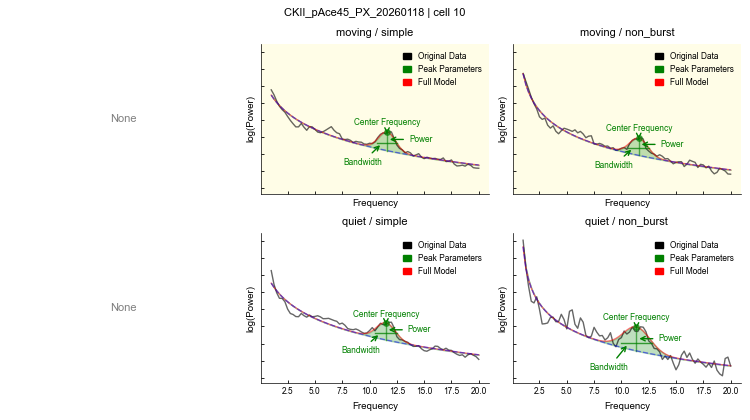

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell11_fooof_2x3.svg


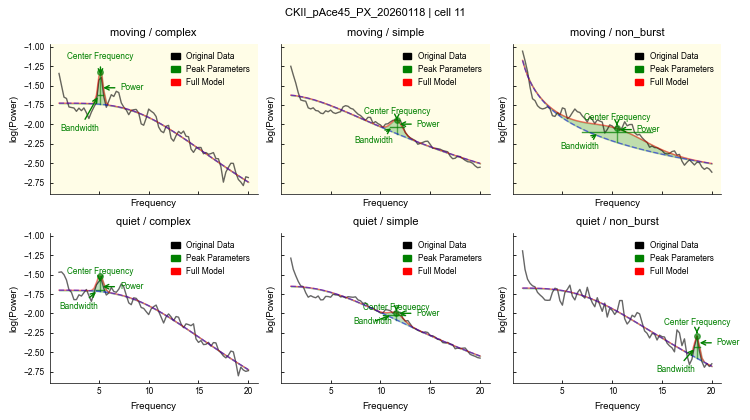

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell12_fooof_2x3.svg


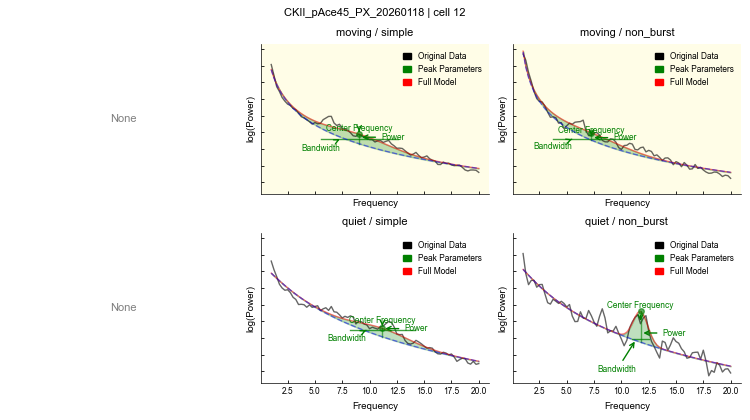

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell13_fooof_2x3.svg


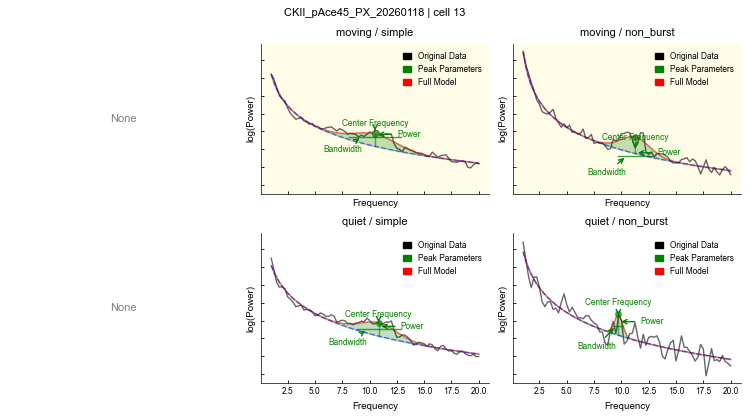

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell14_fooof_2x3.svg


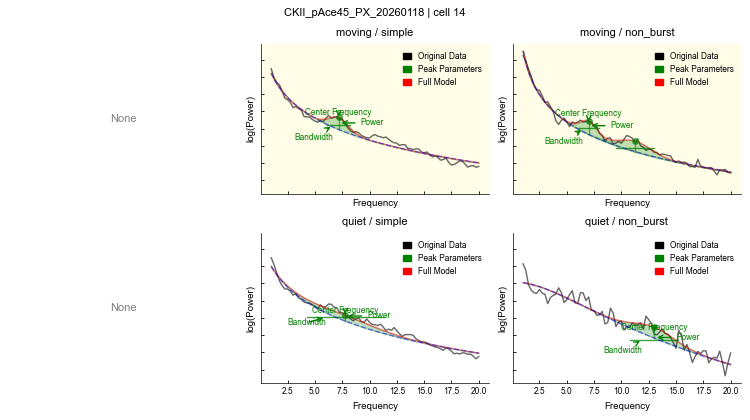

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce45_PX_20260118_cell15_fooof_2x3.svg


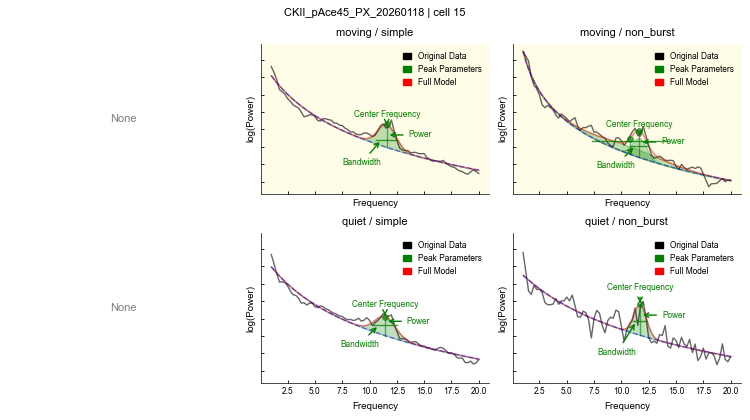

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce47_PX_20260128_cell0_fooof_2x3.svg


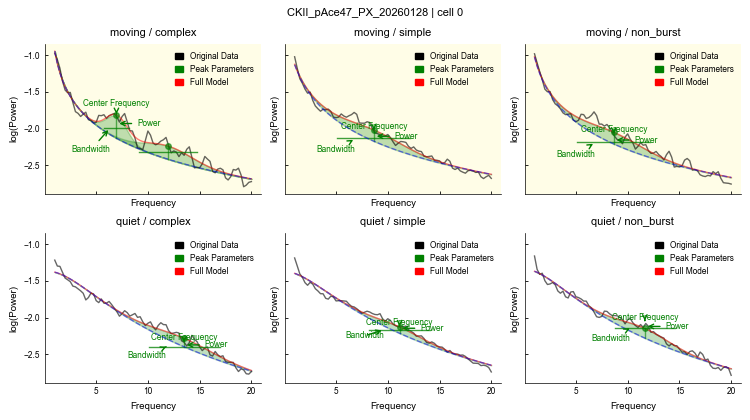

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce47_PX_20260128_cell1_fooof_2x3.svg


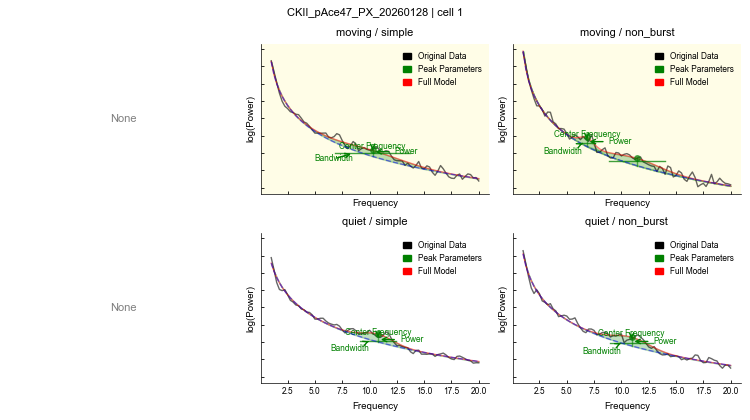

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce47_PX_20260128_cell2_fooof_2x3.svg


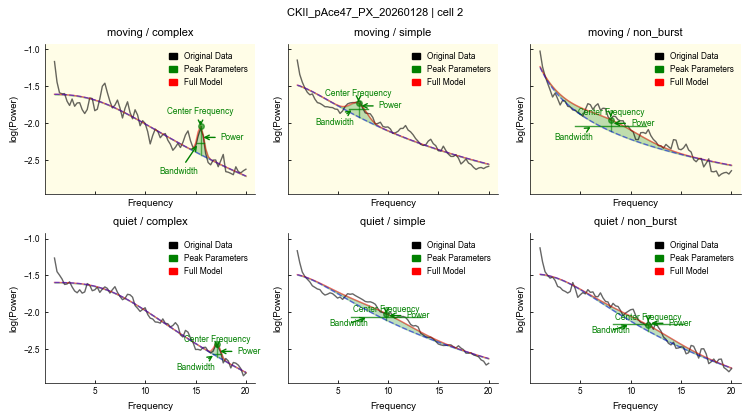

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce47_PX_20260128_cell3_fooof_2x3.svg


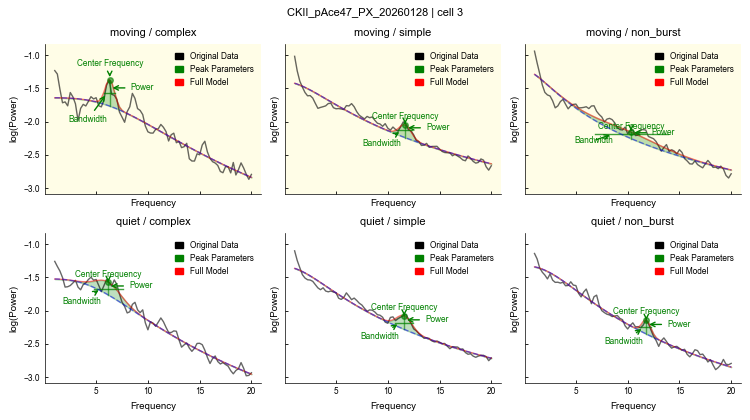

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce47_PX_20260128_cell4_fooof_2x3.svg


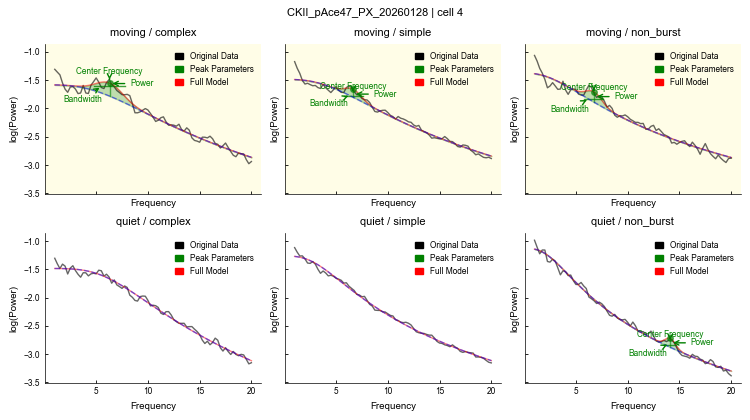

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell0_fooof_2x3.svg


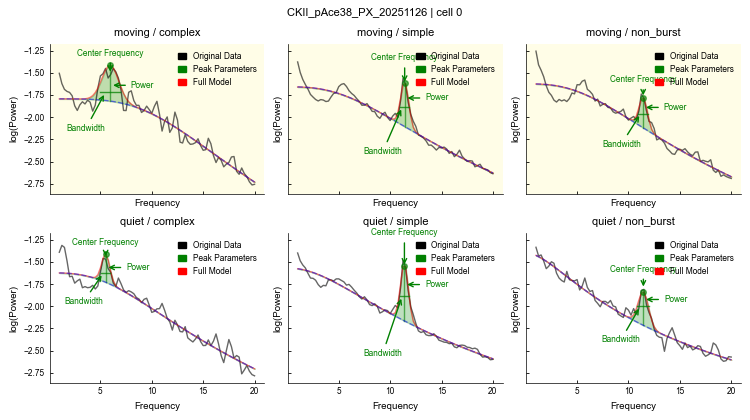

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell1_fooof_2x3.svg


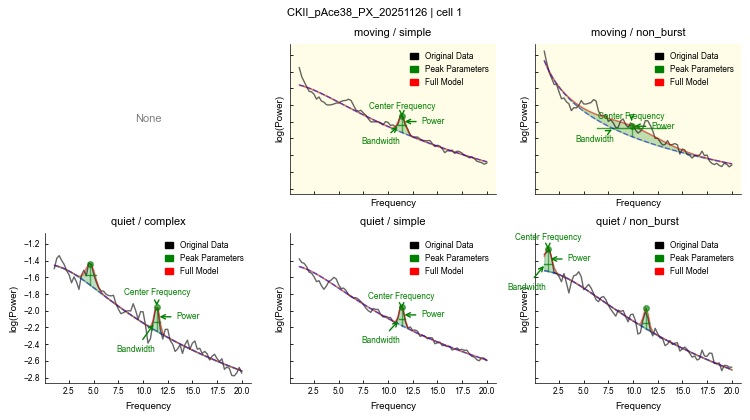

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell2_fooof_2x3.svg


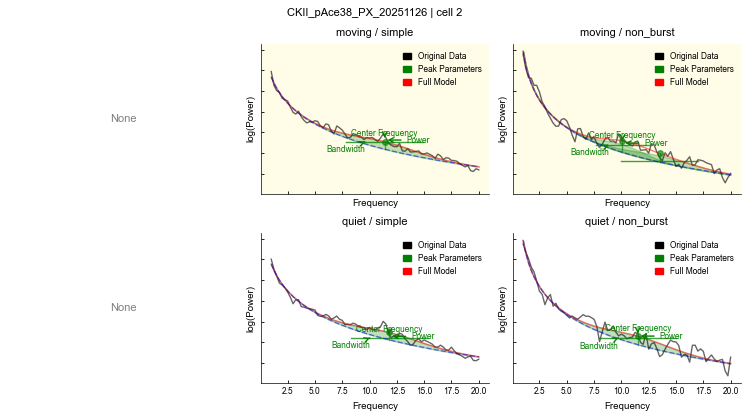

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell3_fooof_2x3.svg


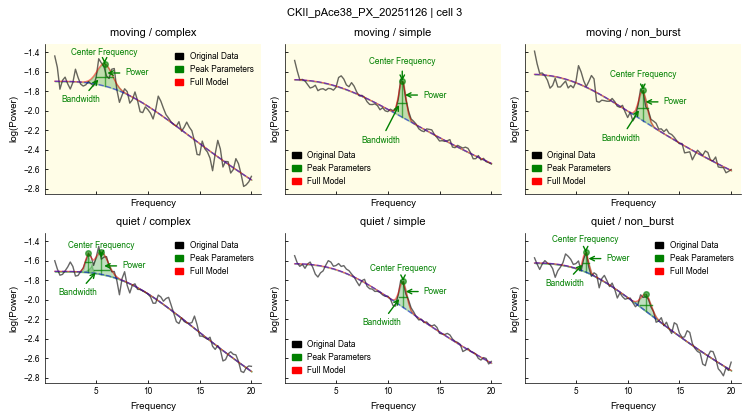

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell4_fooof_2x3.svg


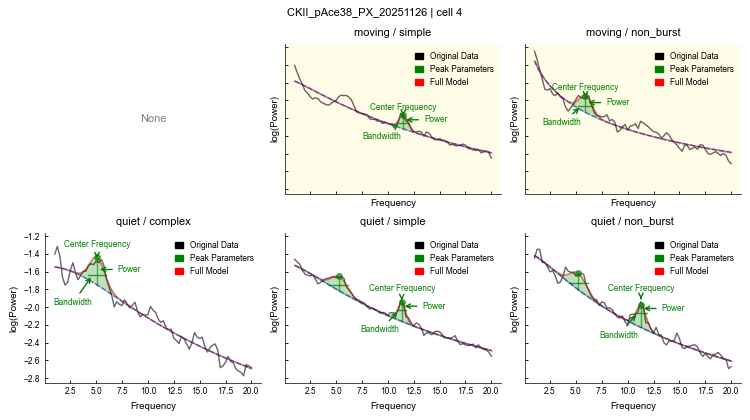

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell5_fooof_2x3.svg


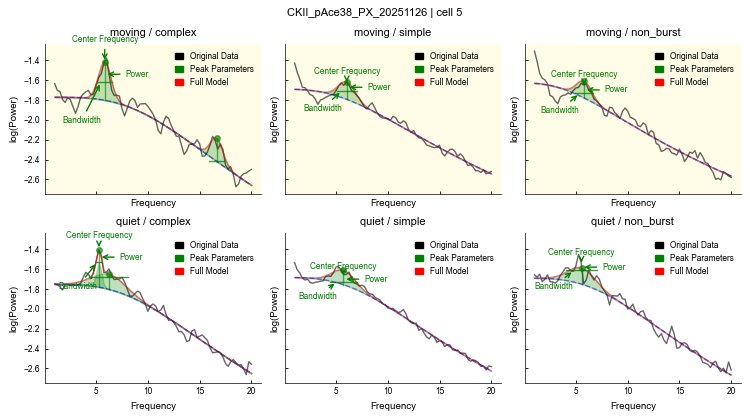

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell6_fooof_2x3.svg


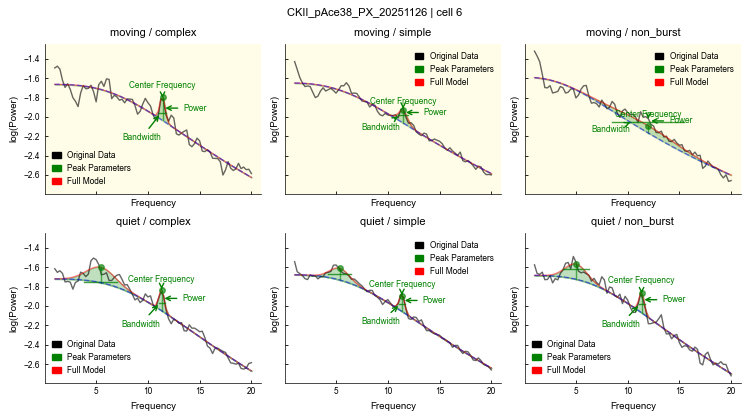

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell7_fooof_2x3.svg


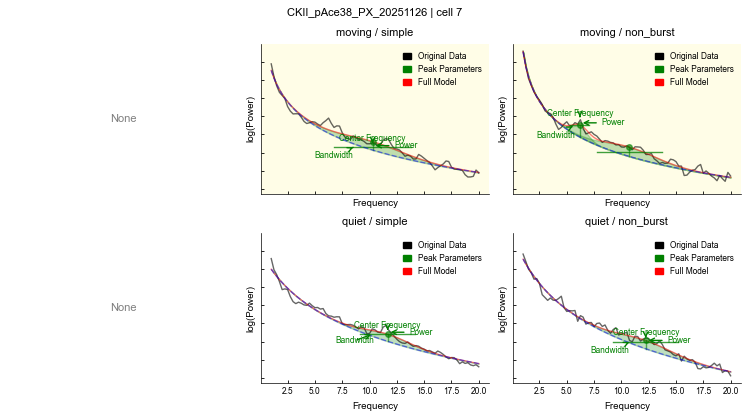

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_annotated_per_cell_2x3/CKII_pAce38_PX_20251126_cell8_fooof_2x3.svg


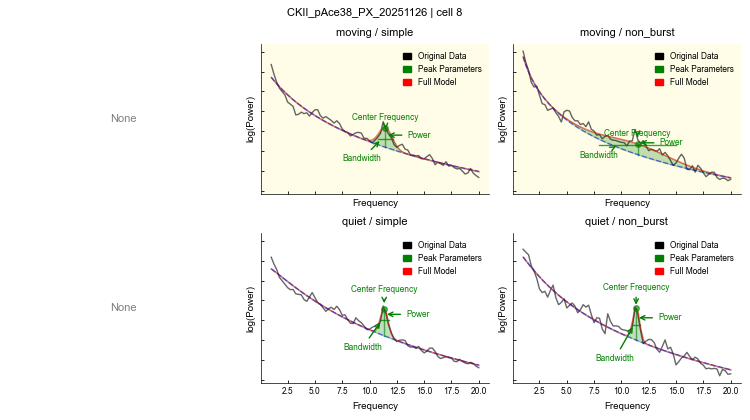

In [8]:
# Plot per-cell annotated FOOOF fits for all 6 conditions (2x3)
# Requires `cell_indices` saved in each *.npz (maps each PSD row back to original cell_idx).

save_plots = True
show_plots = True
max_cells_per_dataset = None  # set to an int to limit (e.g. 10)

annotated_save_folder = os.path.join(figure_save_folder, 'PSD_fooof_annotated_per_cell_2x3')
os.makedirs(annotated_save_folder, exist_ok=True)

conditions_2x3 = [
    ('moving', 'complex'), ('moving', 'simple'), ('moving', 'non_burst'),
    ('quiet', 'complex'),  ('quiet', 'simple'),  ('quiet', 'non_burst'),
]

key_map = {
    ('moving', 'complex'): 'psd_moving_complex',
    ('moving', 'simple'): 'psd_moving_simple',
    ('quiet', 'complex'): 'psd_quiet_complex',
    ('quiet', 'simple'): 'psd_quiet_simple',
    ('moving', 'non_burst'): 'psd_moving_nonburst',
    ('quiet', 'non_burst'): 'psd_quiet_nonburst',
}

for npz_path in npz_files:
    data = np.load(npz_path, allow_pickle=True)
    dataset_name = os.path.basename(os.path.dirname(npz_path))
    freqs = data['freqs']

    if 'cell_indices' not in data.files:
        print(f'Skipping {dataset_name}: no cell_indices saved in npz')
        continue

    cell_indices_local = data['cell_indices'].item()

    # Build row-index lookup: for each npz_key, map cell_idx -> row index
    row_lookup = {}
    for cond, npz_key in key_map.items():
        inds = cell_indices_local.get(npz_key, [])
        row_lookup[npz_key] = {int(ci): i for i, ci in enumerate(inds)}

    all_cells = sorted(set().union(*[set(row_lookup[npz_key].keys()) for npz_key in row_lookup]))
    if max_cells_per_dataset is not None:
        all_cells = all_cells[:max_cells_per_dataset]

    for cell_idx in all_cells:
        fig, axes = plt.subplots(2, 3, figsize=(7.5, 4.2), sharex=True, sharey=True)

        for ax, (state, burst_type) in zip(axes.ravel(), conditions_2x3):
            npz_key = key_map[(state, burst_type)]
            row_idx = row_lookup[npz_key].get(int(cell_idx), None)
            psd = data[npz_key][row_idx] if row_idx is not None and data[npz_key].size else None

            # Light yellow background for moving row
            if state == 'moving':
                ax.set_facecolor('#FFFDE7')


            if psd is None:
                ax.text(0.5, 0.5, 'None', ha='center', va='center', transform=ax.transAxes,
                        fontsize=8, color='gray')
                ax.set_axis_off()
                continue

            fm = FOOOF(
                min_peak_height=min_peak_height,
                aperiodic_mode=aperiodic_mode,
                peak_width_limits=peak_width_limits,
                peak_threshold=peak_threshold,
                max_n_peaks=max_n_peaks,
                verbose=False,
            )

            fm.fit(freqs, psd, freq_range)
            plot_annotated_model(fm, annotate_peaks=True, annotate_aperiodic=False,
                                plt_log=False, ax=ax)

            # Reset styling to match global rcParams
            ax.tick_params(axis='both', which='major', labelsize=6, length=2.0, width=0.6, direction='in')
            ax.set_xlabel('Frequency', fontsize=7)
            ax.set_ylabel('log(Power)', fontsize=7)
            for line in ax.get_lines():
                line.set_linewidth(1.)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            title = f"{state} / {burst_type}"
            ax.set_title(title, fontsize=8)

        fig.suptitle(f'{dataset_name} | cell {cell_idx}', fontsize=8)
        plt.tight_layout()

        if save_plots:
            out_path = os.path.join(annotated_save_folder, f'{dataset_name}_cell{cell_idx}_fooof_2x3.svg')
            fig.savefig(out_path, dpi=300)
            print(f'Saved to {out_path}')

        if show_plots:
            plt.show()
        else:
            plt.close(fig)


# Population fitting

In [9]:
# Model settings
bands = Bands({'theta': [4, 8.],
               'alpha': [8.5, 12]})
peak_width = [1, 5]
n_peaks = 2
peak_height = 0.15
aperiodic_mode = 'knee' #'knee'
PSD_range = [1, 20]

In [10]:
# Fit FOOOFGroup for all 6 conditions and extract theta/alpha peaks
conditions = [
    ('moving', 'complex'),
    ('moving', 'simple'),
    ('moving', 'non_burst'),
    ('quiet', 'complex'),
    ('quiet', 'simple'),
    ('quiet', 'non_burst'),
]

color_map = {
    'complex': complex_color,
    'simple': simple_color,
    'non_burst': non_burst_color,
}

label_map = {
    'complex': 'Complex',
    'simple': 'Non-complex',
    'non_burst': 'Non-burst',
}


fg_results = {}
theta_results = {}
alpha_results = {}

for state, burst_type in conditions:
    spectra = np.array(psd_grand[(state, burst_type)])
    print(f'{state} / {burst_type}: {spectra.shape[0]} cells')
    
    fg = FOOOFGroup(peak_width_limits=peak_width, max_n_peaks=n_peaks,
                    min_peak_height=peak_height, aperiodic_mode=aperiodic_mode, verbose=False)
    fg.fit(freqs_ref, spectra, PSD_range)
    
    thetas = get_band_peak_fg(fg, bands.theta)
    alphas = get_band_peak_fg(fg, bands.alpha)
    fg_results[(state, burst_type)] = fg
    theta_results[(state, burst_type)] = thetas
    alpha_results[(state, burst_type)] = alphas

print('\nFitting complete for all 6 conditions.')


moving / complex: 14 cells
moving / simple: 39 cells
moving / non_burst: 39 cells


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/fooof/core/funcs.py:67: RuntimeWarning: invalid value encountered in log10
  ys = ys + offset - np.log10(knee + xs**exp)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/fooof/core/funcs.py:67: RuntimeWarning: invalid value encountered in log10
  ys = ys + offset - np.log10(knee + xs**exp)


quiet / complex: 22 cells
quiet / simple: 39 cells
quiet / non_burst: 39 cells

Fitting complete for all 6 conditions.


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_peak_params_all_conditions.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


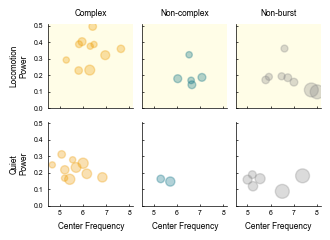

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_alpha_peak_params_all_conditions.svg


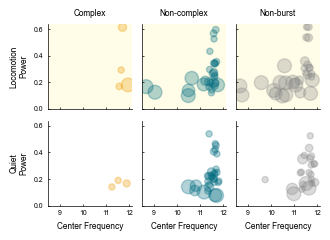

In [11]:
# Plot peak parameters: 2 rows (moving/quiet) x 3 columns (complex/simple/non_burst)
from fooof.plts.periodic import plot_peak_params

fig, axes = plt.subplots(2, 3, figsize=(3.3, 2.4), sharey=True, sharex=True)

burst_order = ['complex', 'simple', 'non_burst']
state_order = ['moving', 'quiet']

for row, state in enumerate(state_order):
    for col, burst_type in enumerate(burst_order):
        ax = axes[row, col]
        thetas = theta_results[(state, burst_type)]
        color = color_map[burst_type]
        
        plot_peak_params(thetas, ax=ax, colors=color, alpha=0.3, s=20)
        
        # Light yellow background for moving (top row)
        if state == 'moving':
            ax.set_facecolor('#FFFDE7')
        
        # Column titles on top row only
        if row == 0:
            ax.set_title(label_map[burst_type], fontsize=6)
        
        # Reset tick params to match global rcParams (fooof overrides them)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5,
                       direction='in')
        
        # Only show xlabel on bottom row
        if row == 1:
            ax.set_xlabel('Center Frequency', fontsize=6)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
        
        # Only show ylabel on left column
        if col == 0:
            state_label = 'Locomotion' if state == 'moving' else 'Quiet'
            ax.set_ylabel(state_label + '\nPower', fontsize=6)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_peak_params_all_conditions.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Plot alpha peak parameters (separate figure)
fig, axes = plt.subplots(2, 3, figsize=(3.3, 2.4), sharey=True, sharex=True)

for row, state in enumerate(state_order):
    for col, burst_type in enumerate(burst_order):
        ax = axes[row, col]
        alphas = alpha_results[(state, burst_type)]
        color = color_map[burst_type]
        
        plot_peak_params(alphas, ax=ax, colors=color, alpha=0.3, s=20)
        
        # Light yellow background for moving (top row)
        if state == 'moving':
            ax.set_facecolor('#FFFDE7')
        
        # Column titles on top row only
        if row == 0:
            ax.set_title(label_map[burst_type], fontsize=6)
        
        # Reset tick params to match global rcParams (fooof overrides them)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5,
                       direction='in')
        
        # Only show xlabel on bottom row
        if row == 1:
            ax.set_xlabel('Center Frequency', fontsize=6)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
        
        # Only show ylabel on left column
        if col == 0:
            state_label = 'Locomotion' if state == 'moving' else 'Quiet'
            ax.set_ylabel(state_label + '\nPower', fontsize=6)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_alpha_peak_params_all_conditions.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_peak_fits_all_conditions.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


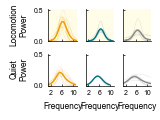

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_alpha_peak_fits_all_conditions.svg


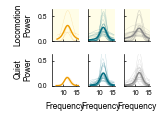

In [12]:
# Plot peak fits: 2 rows (moving/quiet) x 3 columns (complex/simple/non_burst)
from fooof.plts.periodic import plot_peak_fits

figsize = (1.6, 1.2)

fig, axes = plt.subplots(2, 3, figsize=figsize, sharey=True, sharex=True)

for row, state in enumerate(state_order):
    for col, burst_type in enumerate(burst_order):
        ax = axes[row, col]
        thetas = theta_results[(state, burst_type)]
        color = color_map[burst_type]
        
        plot_peak_fits(thetas, ax=ax, colors=color)
        
        
        # Light yellow background for moving (top row)
        if state == 'moving':
            ax.set_facecolor('#FFFDE7')
        
        # Column titles on top row only
        # if row == 0:
        #     ax.set_title(label_map[burst_type], fontsize=6)
        
        # Reset tick params to match global rcParams (fooof overrides them)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5,
                       direction='in')
        
        # Only show xlabel on bottom row
        if row == 1:
            ax.set_xlabel('Frequency', fontsize=6)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
        
        # Only show ylabel on left column
        if col == 0:
            state_label = 'Locomotion' if state == 'moving' else 'Quiet'
            ax.set_ylabel(state_label + '\nPower', fontsize=6)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
ax.set_xticks([2,6,10])
plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_peak_fits_all_conditions.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Plot alpha peak fits (separate figure)
fig, axes = plt.subplots(2, 3, figsize=figsize, sharey=True, sharex=True)

for row, state in enumerate(state_order):
    for col, burst_type in enumerate(burst_order):
        ax = axes[row, col]
        alphas = alpha_results[(state, burst_type)]
        color = color_map[burst_type]
        
        plot_peak_fits(alphas, ax=ax, colors=color)
        
        # Light yellow background for moving (top row)
        if state == 'moving':
            ax.set_facecolor('#FFFDE7')
        
        # Column titles on top row only
        # if row == 0:
        #     ax.set_title(label_map[burst_type], fontsize=6)
        
        # Reset tick params to match global rcParams (fooof overrides them)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5,
                       direction='in')
        
        # Only show xlabel on bottom row
        if row == 1:
            ax.set_xlabel('Frequency', fontsize=6)
        else:
            ax.set_xlabel('')
            ax.tick_params(axis='x', labelbottom=False)
        
        # Only show ylabel on left column
        if col == 0:
            state_label = 'Locomotion' if state == 'moving' else 'Quiet'
            ax.set_ylabel(state_label + '\nPower', fontsize=6)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_alpha_peak_fits_all_conditions.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()


In [13]:
# Extract peak metrics from theta_results for all 6 conditions
# Columns: [CF, Power, BW]
# AUC: area under (full model - aperiodic fit) within the band

import pandas as pd

def band_auc_from_fg(fg, idx, band, clip_zero=True, space='linear'):
    """Integrate periodic component within a frequency band.

    Periodic component is (full model - aperiodic). With space='linear', this is in
    linear power units; integrate w.r.t. frequency to get an area-like measure.
    """
    try:
        fm = fg.get_fooof(idx, regenerate=True)
        freqs = fm.freqs
        f_lo, f_hi = band
        mask = (freqs >= f_lo) & (freqs <= f_hi)
        if not np.any(mask):
            return np.nan
        peak = fm.get_model('peak', space=space)
        vals = peak[mask]
        if clip_zero:
            vals = np.clip(vals, 0, None)
        return float(np.trapezoid(vals, freqs[mask]))
    except Exception:
        return np.nan

metrics_rows = []

for state, burst_type in conditions:
    thetas = theta_results[(state, burst_type)]
    fg = fg_results[(state, burst_type)]
    for i in range(thetas.shape[0]):
        cf, pw, bw = thetas[i]
        if np.isnan(cf):
            continue  # skip cells with no detected theta peak
        auc = band_auc_from_fg(fg, i, bands.theta)
        metrics_rows.append({
            'state': state,
            'burst_type': burst_type,
            'CF': cf,
            'Power': pw,
            'BW': bw,
            'AUC': auc,
        })

df_metrics = pd.DataFrame(metrics_rows)

# Detection rate: % of cells with a detected theta peak (non-NaN CF)
detect_rows = []
for state, burst_type in conditions:
    thetas = theta_results[(state, burst_type)]
    n_total = int(thetas.shape[0])
    n_detect = int(np.sum(~np.isnan(thetas[:, 0])))
    pct_detect = (100.0 * n_detect / n_total) if n_total else np.nan
    detect_rows.append({
        'state': state,
        'burst_type': burst_type,
        'n_total': n_total,
        'n_detect': n_detect,
        'pct_detect': pct_detect,
    })
df_peak_detect = pd.DataFrame(detect_rows)

print(f'Total cells with detected theta peaks: {len(df_metrics)}')
print()
for (state, burst_type), grp in df_metrics.groupby(['state', 'burst_type']):
    print(f'  {state:>7s} / {burst_type:<10s}: n={len(grp):3d}  '
          f'CF={grp["CF"].mean():.2f}±{grp["CF"].std():.2f}  '
          f'PW={grp["Power"].mean():.3f}±{grp["Power"].std():.3f}  '
          f'BW={grp["BW"].mean():.2f}±{grp["BW"].std():.2f}  '
          f'AUC={grp["AUC"].mean():.3f}±{grp["AUC"].std():.3f}')

print('\nTheta peak detection rate (% of cells with detected theta peak):')
for _, row in df_peak_detect.sort_values(['state', 'burst_type']).iterrows():
    print(f"  {row['state']:>7s} / {row['burst_type']:<10s}: {row['n_detect']}/{row['n_total']} = {row['pct_detect']:.1f}%")

# Extract peak metrics from alpha_results (separate from theta)
alpha_rows = []
for state, burst_type in conditions:
    alphas = alpha_results[(state, burst_type)]
    fg = fg_results[(state, burst_type)]
    for i in range(alphas.shape[0]):
        cf, pw, bw = alphas[i]
        if np.isnan(cf):
            continue  # skip cells with no detected alpha peak
        auc = band_auc_from_fg(fg, i, bands.alpha)
        alpha_rows.append({
            'state': state,
            'burst_type': burst_type,
            'CF': cf,
            'Power': pw,
            'BW': bw,
            'AUC': auc,
        })
df_metrics_alpha = pd.DataFrame(alpha_rows)

# Detection rate: % of cells with a detected alpha peak (non-NaN CF)
alpha_detect_rows = []
for state, burst_type in conditions:
    alphas = alpha_results[(state, burst_type)]
    n_total = int(alphas.shape[0])
    n_detect = int(np.sum(~np.isnan(alphas[:, 0])))
    pct_detect = (100.0 * n_detect / n_total) if n_total else np.nan
    alpha_detect_rows.append({
        'state': state,
        'burst_type': burst_type,
        'n_total': n_total,
        'n_detect': n_detect,
        'pct_detect': pct_detect,
    })
df_peak_detect_alpha = pd.DataFrame(alpha_detect_rows)

print(f'\nTotal cells with detected alpha peaks: {len(df_metrics_alpha)}')
print('\nAlpha peak detection rate (% of cells with detected alpha peak):')
for _, row in df_peak_detect_alpha.sort_values(['state', 'burst_type']).iterrows():
    print(f"  {row['state']:>7s} / {row['burst_type']:<10s}: {row['n_detect']}/{row['n_total']} = {row['pct_detect']:.1f}%")


Total cells with detected theta peaks: 41

   moving / complex   : n= 10  CF=6.30±0.66  PW=0.348±0.082  BW=1.47±0.50  AUC=0.470±0.230
   moving / non_burst : n=  8  CF=6.78±0.79  PW=0.183±0.080  BW=2.29±1.68  AUC=0.111±0.102
   moving / simple    : n=  5  CF=6.58±0.37  PW=0.200±0.071  BW=1.38±0.28  AUC=0.135±0.077
    quiet / complex   : n= 10  CF=5.59±0.62  PW=0.223±0.051  BW=1.87±0.71  AUC=0.385±0.160
    quiet / non_burst : n=  6  CF=5.81±0.93  PW=0.149±0.039  BW=3.08±1.53  AUC=0.197±0.088
    quiet / simple    : n=  2  CF=5.51±0.29  PW=0.154±0.011  BW=1.84±0.51  AUC=0.143±0.075

Theta peak detection rate (% of cells with detected theta peak):
   moving / complex   : 10/14 = 71.4%
   moving / non_burst : 8/39 = 20.5%
   moving / simple    : 5/39 = 12.8%
    quiet / complex   : 10/22 = 45.5%
    quiet / non_burst : 6/39 = 15.4%
    quiet / simple    : 2/39 = 5.1%

Total cells with detected alpha peaks: 122

Alpha peak detection rate (% of cells with detected alpha peak):
   moving / 

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_theta_metrics_violin.svg


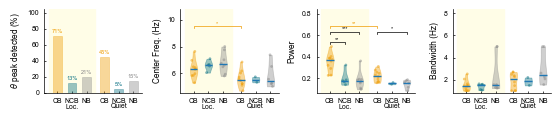

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PSD_fooof_alpha_metrics_violin.svg


/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


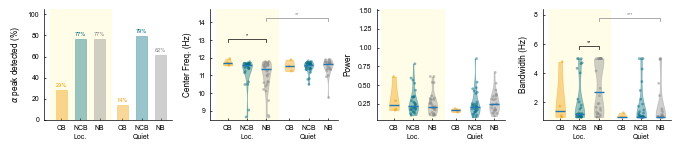

In [14]:
# Violin plots: 1x4 combined layout, Loc and Quiet side by side with gap

plot_auc = False
VIOLIN_MEDIAN_COLOR = '#1F77B4'
metric_names = ['pct_detect', 'CF', 'Power', 'BW'] + (['AUC'] if plot_auc else [])
metric_labels = [r'$\theta$ peak detected (%)', 'Center Freq. (Hz)', 'Power', 'Bandwidth (Hz)'] + (['AUC'] if plot_auc else [])

# Positions: Locomotion at 0,1,2; Quiet at 4,5,6 (gap of 1 between groups)
loc_pos = [0, 1, 2]
quiet_pos = [3.2, 4.2, 5.2]

# Controls for significance annotations
show_nonsig = False  # if False, skip drawing non-significant (n.s.) comparisons
alpha = 0.05

def sig_label(p, alpha=alpha):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < alpha: return '*'
    else: return 'n.s.'

def should_draw_sig(p, show_nonsig=show_nonsig, alpha=alpha):
    return show_nonsig or (p < alpha)

def draw_bracket(ax, x1, x2, y, h, text, lw=0.5, fontsize=4, color='k', text_pad=0):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, color=color, clip_on=False)
    ax.text((x1 + x2) / 2, y + h + text_pad, text, ha='center', va='bottom', fontsize=fontsize, color=color)

n_panels = len(metric_names)
fig, axes = plt.subplots(1, n_panels, figsize=(1.4 * n_panels, 1.2))
axes = np.atleast_1d(axes)

for col, (metric, title) in enumerate(zip(metric_names, metric_labels)):
    ax = axes[col]
    
    # Yellow background for locomotion region
    ax.axvspan(-0.6, 2.6, color='#FFFDE7', zorder=0)
    
    all_vals_flat = []
    data_cache = {}
    
    # Special panel: percent of cells with detected theta peak
    if metric == 'pct_detect':
        for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
            for pos, burst_type in zip(positions, burst_order):
                row = df_peak_detect[(df_peak_detect['state'] == state) & (df_peak_detect['burst_type'] == burst_type)]
                if row.empty:
                    continue
                pct = float(row['pct_detect'].iloc[0])
                if np.isnan(pct):
                    continue
                all_vals_flat.append(pct)
                c = color_map[burst_type]
                ax.bar(pos, pct, width=0.6, color=c, alpha=0.4, edgecolor=c, linewidth=0.5, zorder=2)
                ax.text(pos, pct + 2, f'{pct:.0f}%', ha='center', va='bottom', fontsize=4, color=c)

        ax.set_ylim(0, 105)

        # X-axis
        all_pos = loc_pos + quiet_pos
        ax.set_xticks(all_pos)
        ax.set_xticklabels(['CB', 'NCB', 'NB'] * 2)

        # Group labels below x-axis
        ax.text(np.mean(loc_pos), -0.13, 'Loc.', ha='center', va='top',
                fontsize=5, transform=ax.get_xaxis_transform())
        ax.text(np.mean(quiet_pos), -0.13, 'Quiet', ha='center', va='top',
                fontsize=5, transform=ax.get_xaxis_transform())

        ax.set_ylabel(title, fontsize=6)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue

    for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
        df_state = df_metrics[df_metrics['state'] == state]
        
        data_list = []
        colors_list = []
        for pos, burst_type in zip(positions, burst_order):
            vals = df_state.loc[df_state['burst_type'] == burst_type, metric].dropna().values
            data_list.append(vals)
            colors_list.append(color_map[burst_type])
            all_vals_flat.extend(vals)
            data_cache[(state, burst_type)] = vals
        
        # Only plot violins for groups with enough data
        valid_mask = [len(d) >= 2 for d in data_list]
        if any(valid_mask):
            valid_data = [d for d, v in zip(data_list, valid_mask) if v]
            valid_pos = [p for p, v in zip(positions, valid_mask) if v]
            valid_colors = [c for c, v in zip(colors_list, valid_mask) if v]
            
            parts = ax.violinplot(valid_data, positions=valid_pos, showmeans=False,
                                  showmedians=False, showextrema=False)
            for pc, c in zip(parts['bodies'], valid_colors):
                pc.set_facecolor(c)
                pc.set_alpha(0.4)
                pc.set_edgecolor(c)
                pc.set_linewidth(0.5)
        
        for pos, vals, c in zip(positions, data_list, colors_list):
            if len(vals) == 0:
                continue
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(np.full_like(vals, pos) + jitter, vals, s=4, alpha=0.5,
                       color=c, edgecolors='none', zorder=3)
            ax.hlines(np.median(vals), pos - 0.25, pos + 0.25, color=VIOLIN_MEDIAN_COLOR,
                      linewidth=1., zorder=4)
    
    if len(all_vals_flat) == 0:
        continue
    
    y_max = np.max(all_vals_flat)
    y_min = np.min(all_vals_flat)
    y_range = y_max - y_min if y_max > y_min else 1.0
    h = y_range * 0.05       # bracket cap height
    step = y_range * 0.12    # vertical gap between bracket levels
    base_y = y_max + y_range * 0.05
    text_pad = 0       # extra gap between bracket and text
    
    # --- Within-state brackets ---
    # Loc and Quiet brackets at same levels (they don't overlap in x)
    # Level 0: adjacent left pair; Level 1: adjacent right pair; Level 2: spanning pair
    within_specs = [
        (0, 1, 0),  # (burst_idx_a, burst_idx_b, level)
        (1, 2, 1),
        (0, 2, 2),
    ]
    
    for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
        for idx_a, idx_b, level in within_specs:
            bt_a, bt_b = burst_order[idx_a], burst_order[idx_b]
            vals_a = data_cache.get((state, bt_a), np.array([]))
            vals_b = data_cache.get((state, bt_b), np.array([]))
            if len(vals_a) >= 3 and len(vals_b) >= 3:
                _, p = stats.mannwhitneyu(vals_a, vals_b, alternative='two-sided')
                y = base_y + level * step
                if should_draw_sig(p):
                    draw_bracket(ax, positions[idx_a], positions[idx_b], y, h, sig_label(p), text_pad=text_pad)
    
    # --- Between-state brackets (same burst type) ---
    between_base = base_y + 3 * step  # start above within-state brackets
    for i, burst_type in enumerate(burst_order):
        vals_mov = data_cache.get(('moving', burst_type), np.array([]))
        vals_qui = data_cache.get(('quiet', burst_type), np.array([]))
        if len(vals_mov) >= 3 and len(vals_qui) >= 3:
            _, p = stats.mannwhitneyu(vals_mov, vals_qui, alternative='two-sided')
            y = between_base + i * step
            if should_draw_sig(p):
                draw_bracket(ax, loc_pos[i], quiet_pos[i], y, h, sig_label(p),
                             color=color_map[burst_type], text_pad=text_pad)
    
    # Adjust y-axis to fit all brackets
    top_y = between_base + 2 * step + h * 4 + text_pad * 2
    ax.set_ylim(y_min - y_range * 0.05, top_y)
    
    # X-axis
    all_pos = loc_pos + quiet_pos
    ax.set_xticks(all_pos)
    ax.set_xticklabels(['CB', 'NCB', 'NB'] * 2)
    
    # Group labels below x-axis
    ax.text(np.mean(loc_pos), -0.13, 'Loc.', ha='center', va='top',
            fontsize=5, transform=ax.get_xaxis_transform())
    ax.text(np.mean(quiet_pos), -0.13, 'Quiet', ha='center', va='top',
            fontsize=5, transform=ax.get_xaxis_transform())
    
    ax.set_ylabel(title, fontsize=6)
    ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_theta_metrics_violin.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()

# Alpha metrics violin plot (separate figure)
metric_names = ['pct_detect', 'CF', 'Power', 'BW'] + (['AUC'] if plot_auc else [])
metric_labels = [r'$\alpha$ peak detected (%)', 'Center Freq. (Hz)', 'Power', 'Bandwidth (Hz)'] + (['AUC'] if plot_auc else [])

n_panels = len(metric_names)
fig, axes = plt.subplots(1, n_panels, figsize=(1.7 * n_panels, 1.5))
axes = np.atleast_1d(axes)

for col, (metric, title) in enumerate(zip(metric_names, metric_labels)):
    ax = axes[col]
    
    # Yellow background for locomotion region
    ax.axvspan(-0.6, 2.6, color='#FFFDE7', zorder=0)
    
    all_vals_flat = []
    data_cache = {}
    
    # Special panel: percent of cells with detected alpha peak
    if metric == 'pct_detect':
        for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
            for pos, burst_type in zip(positions, burst_order):
                row = df_peak_detect_alpha[(df_peak_detect_alpha['state'] == state) & (df_peak_detect_alpha['burst_type'] == burst_type)]
                if row.empty:
                    continue
                pct = float(row['pct_detect'].iloc[0])
                if np.isnan(pct):
                    continue
                all_vals_flat.append(pct)
                c = color_map[burst_type]
                ax.bar(pos, pct, width=0.6, color=c, alpha=0.4, edgecolor=c, linewidth=0.5, zorder=2)
                ax.text(pos, pct + 2, f'{pct:.0f}%', ha='center', va='bottom', fontsize=4, color=c)

        ax.set_ylim(0, 105)

        # X-axis
        all_pos = loc_pos + quiet_pos
        ax.set_xticks(all_pos)
        ax.set_xticklabels(['CB', 'NCB', 'NB'] * 2)

        # Group labels below x-axis
        ax.text(np.mean(loc_pos), -0.13, 'Loc.', ha='center', va='top',
                fontsize=5, transform=ax.get_xaxis_transform())
        ax.text(np.mean(quiet_pos), -0.13, 'Quiet', ha='center', va='top',
                fontsize=5, transform=ax.get_xaxis_transform())

        ax.set_ylabel(title, fontsize=6)
        ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue

    for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
        df_state = df_metrics_alpha[df_metrics_alpha['state'] == state]
        
        data_list = []
        colors_list = []
        for pos, burst_type in zip(positions, burst_order):
            vals = df_state.loc[df_state['burst_type'] == burst_type, metric].dropna().values
            data_list.append(vals)
            colors_list.append(color_map[burst_type])
            all_vals_flat.extend(vals)
            data_cache[(state, burst_type)] = vals
        
        # Only plot violins for groups with enough data
        valid_mask = [len(d) >= 2 for d in data_list]
        if any(valid_mask):
            valid_data = [d for d, v in zip(data_list, valid_mask) if v]
            valid_pos = [p for p, v in zip(positions, valid_mask) if v]
            valid_colors = [c for c, v in zip(colors_list, valid_mask) if v]
            
            parts = ax.violinplot(valid_data, positions=valid_pos, showmeans=False,
                                  showmedians=False, showextrema=False)
            for pc, c in zip(parts['bodies'], valid_colors):
                pc.set_facecolor(c)
                pc.set_alpha(0.4)
                pc.set_edgecolor(c)
                pc.set_linewidth(0.5)
        
        for pos, vals, c in zip(positions, data_list, colors_list):
            if len(vals) == 0:
                continue
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
            ax.scatter(np.full_like(vals, pos) + jitter, vals, s=4, alpha=0.5,
                       color=c, edgecolors='none', zorder=3)
            ax.hlines(np.median(vals), pos - 0.25, pos + 0.25, color=VIOLIN_MEDIAN_COLOR,
                      linewidth=1., zorder=4)
    
    if len(all_vals_flat) == 0:
        continue
    
    y_max = np.max(all_vals_flat)
    y_min = np.min(all_vals_flat)
    y_range = y_max - y_min if y_max > y_min else 1.0
    h = y_range * 0.05       # bracket cap height
    step = y_range * 0.12    # vertical gap between bracket levels
    base_y = y_max + y_range * 0.05
    text_pad = 0       # extra gap between bracket and text
    
    # --- Within-state brackets ---
    within_specs = [
        (0, 1, 0),
        (1, 2, 1),
        (0, 2, 2),
    ]
    
    for state, positions in [('moving', loc_pos), ('quiet', quiet_pos)]:
        for idx_a, idx_b, level in within_specs:
            bt_a, bt_b = burst_order[idx_a], burst_order[idx_b]
            vals_a = data_cache.get((state, bt_a), np.array([]))
            vals_b = data_cache.get((state, bt_b), np.array([]))
            if len(vals_a) >= 3 and len(vals_b) >= 3:
                _, p = stats.mannwhitneyu(vals_a, vals_b, alternative='two-sided')
                y = base_y + level * step
                if should_draw_sig(p):
                    draw_bracket(ax, positions[idx_a], positions[idx_b], y, h, sig_label(p), text_pad=text_pad)
    
    # --- Between-state brackets (same burst type) ---
    between_base = base_y + 3 * step
    for i, burst_type in enumerate(burst_order):
        vals_mov = data_cache.get(('moving', burst_type), np.array([]))
        vals_qui = data_cache.get(('quiet', burst_type), np.array([]))
        if len(vals_mov) >= 3 and len(vals_qui) >= 3:
            _, p = stats.mannwhitneyu(vals_mov, vals_qui, alternative='two-sided')
            y = between_base + i * step
            if should_draw_sig(p):
                draw_bracket(ax, loc_pos[i], quiet_pos[i], y, h, sig_label(p),
                             color=color_map[burst_type], text_pad=text_pad)
    
    # Adjust y-axis to fit all brackets
    top_y = between_base + 2 * step + h * 4 + text_pad * 2
    ax.set_ylim(y_min - y_range * 0.05, top_y)
    
    # X-axis
    all_pos = loc_pos + quiet_pos
    ax.set_xticks(all_pos)
    ax.set_xticklabels(['CB', 'NCB', 'NB'] * 2)
    
    # Group labels below x-axis
    ax.text(np.mean(loc_pos), -0.13, 'Loc.', ha='center', va='top',
            fontsize=5, transform=ax.get_xaxis_transform())
    ax.text(np.mean(quiet_pos), -0.13, 'Quiet', ha='center', va='top',
            fontsize=5, transform=ax.get_xaxis_transform())
    
    ax.set_ylabel(title, fontsize=6)
    ax.tick_params(axis='both', which='major', labelsize=5, length=1.75, width=0.5, direction='in')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

out_path = os.path.join(figure_save_folder, 'PSD_fooof_alpha_metrics_violin.svg')
fig.savefig(out_path, dpi=300)
print(f'Saved to {out_path}')
plt.show()


In [15]:
# Statistical tests
from itertools import combinations

def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

print('=== Statistical Tests: Theta Peak Metrics ===\n')

# Peak metrics live in df_metrics (per-cell). pct_detect is computed separately in df_peak_detect.
metric_names_peak = ['CF', 'Power', 'BW', 'AUC']

# Within-state: Kruskal-Wallis + pairwise Mann-Whitney U
for state, state_label in [('moving', 'Locomotion'), ('quiet', 'Quiet')]:
    print(f'--- {state_label} (within-state) ---')
    df_state = df_metrics[df_metrics['state'] == state]
    
    for metric in metric_names_peak:
        groups = {}
        for burst_type in burst_order:
            vals = df_state.loc[df_state['burst_type'] == burst_type, metric].dropna().values
            groups[burst_type] = vals
        
        valid_groups = [g for g in groups.values() if len(g) >= 3]
        if len(valid_groups) >= 2:
            kw_stat, kw_p = stats.kruskal(*valid_groups)
            print(f'\n  {metric}: Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.3g}')
        
            for (a, b) in combinations(burst_order, 2):
                if len(groups[a]) >= 3 and len(groups[b]) >= 3:
                    u_stat, u_p = stats.mannwhitneyu(groups[a], groups[b], alternative='two-sided')
                    print(f'    {label_map[a]:>12s} vs {label_map[b]:<12s}: '
                          f'U={u_stat:.1f}, p={u_p:.3g} {_sig(u_p)}')
    print()

# Between-state: Loc vs Quiet for same burst type
print('--- Locomotion vs Quiet (between-state, same burst type) ---')
for metric in metric_names_peak:
    print(f'\n  {metric}:')
    for burst_type in burst_order:
        vals_mov = df_metrics.loc[(df_metrics['state'] == 'moving') & (df_metrics['burst_type'] == burst_type), metric].dropna().values
        vals_qui = df_metrics.loc[(df_metrics['state'] == 'quiet') & (df_metrics['burst_type'] == burst_type), metric].dropna().values
        if len(vals_mov) >= 3 and len(vals_qui) >= 3:
            u_stat, u_p = stats.mannwhitneyu(vals_mov, vals_qui, alternative='two-sided')
            print(f'    {label_map[burst_type]:>12s}: Loc (n={len(vals_mov)}) vs Quiet (n={len(vals_qui)})  '
                  f'U={u_stat:.1f}, p={u_p:.3g} {_sig(u_p)}')

# Detection rate stats (counts): pct_detect
print('\n--- Theta peak detection rate (pct_detect) ---')
for state, state_label in [('moving', 'Locomotion'), ('quiet', 'Quiet')]:
    print(f'\n  {state_label} (within-state):')
    tab = []
    ok = True
    for bt in burst_order:
        row = df_peak_detect[(df_peak_detect['state'] == state) & (df_peak_detect['burst_type'] == bt)]
        if row.empty:
            ok = False
            break
        det = int(row['n_detect'].iloc[0])
        tot = int(row['n_total'].iloc[0])
        tab.append([det, tot - det])
    if ok and all((t[0] + t[1]) > 0 for t in tab):
        # Chi-square test on 2x3 table: detected vs not detected across burst types
        chi2, p, dof, _ = stats.chi2_contingency(np.array(tab).T)
        print(f'    Chi2={chi2:.3f}, p={p:.3g}')
        for (a, b) in combinations(burst_order, 2):
            ra = df_peak_detect[(df_peak_detect['state'] == state) & (df_peak_detect['burst_type'] == a)].iloc[0]
            rb = df_peak_detect[(df_peak_detect['state'] == state) & (df_peak_detect['burst_type'] == b)].iloc[0]
            table_2x2 = [[int(ra['n_detect']), int(ra['n_total'] - ra['n_detect'])],
                         [int(rb['n_detect']), int(rb['n_total'] - rb['n_detect'])]]
            _, p2 = stats.fisher_exact(table_2x2)
            pa = float(ra['pct_detect']); pb = float(rb['pct_detect'])
            print(f'    {label_map[a]:>12s} vs {label_map[b]:<12s}: '
                  f'{int(ra["n_detect"])}/{int(ra["n_total"])}={pa:.1f}% vs {int(rb["n_detect"])}/{int(rb["n_total"])}={pb:.1f}%  '
                  f'p={p2:.3g} {_sig(p2)}')
    else:
        print('    (skipped; missing counts)')

print('\n  Locomotion vs Quiet (between-state, same burst type):')
for bt in burst_order:
    rm = df_peak_detect[(df_peak_detect['state'] == 'moving') & (df_peak_detect['burst_type'] == bt)]
    rq = df_peak_detect[(df_peak_detect['state'] == 'quiet') & (df_peak_detect['burst_type'] == bt)]
    if rm.empty or rq.empty:
        continue
    rm = rm.iloc[0]; rq = rq.iloc[0]
    table_2x2 = [[int(rm['n_detect']), int(rm['n_total'] - rm['n_detect'])],
                 [int(rq['n_detect']), int(rq['n_total'] - rq['n_detect'])]]
    _, p = stats.fisher_exact(table_2x2)
    pm = float(rm['pct_detect']); pq = float(rq['pct_detect'])
    print(f'    {label_map[bt]:>12s}: Loc {int(rm["n_detect"])}/{int(rm["n_total"])}={pm:.1f}% vs Quiet {int(rq["n_detect"])}/{int(rq["n_total"])}={pq:.1f}%  '
          f'p={p:.3g} {_sig(p)}')


=== Statistical Tests: Theta Peak Metrics ===

--- Locomotion (within-state) ---

  CF: Kruskal-Wallis H=3.016, p=0.221
         Complex vs Non-complex : U=13.0, p=0.165 n.s.
         Complex vs Non-burst   : U=24.0, p=0.173 n.s.
     Non-complex vs Non-burst   : U=19.0, p=0.943 n.s.

  Power: Kruskal-Wallis H=12.078, p=0.00238
         Complex vs Non-complex : U=46.0, p=0.00799 **
         Complex vs Non-burst   : U=75.0, p=0.000868 ***
     Non-complex vs Non-burst   : U=21.0, p=0.943 n.s.

  BW: Kruskal-Wallis H=0.959, p=0.619
         Complex vs Non-complex : U=23.0, p=0.854 n.s.
         Complex vs Non-burst   : U=28.0, p=0.307 n.s.
     Non-complex vs Non-burst   : U=18.0, p=0.833 n.s.

  AUC: Kruskal-Wallis H=13.877, p=0.00097
         Complex vs Non-complex : U=49.0, p=0.00133 **
         Complex vs Non-burst   : U=76.0, p=0.000548 ***
     Non-complex vs Non-burst   : U=23.0, p=0.724 n.s.

--- Quiet (within-state) ---

  CF: Kruskal-Wallis H=0.047, p=0.828
         Complex vs 